# Time Series Analysis & Anomaly Detection for Multiple Humidity Sensors in a Warehouse 

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
import statsmodels.api as sm

In [30]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData2.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [31]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:05:04,2,02/27/2025 10:05:04 AM,80.08,78.63,76.11,77.18,78.87,78.12,sheet1
2025-02-27 10:05:24,3,02/27/2025 10:05:24 AM,79.94,78.63,76.12,77.15,78.85,78.09,sheet1
2025-02-27 10:05:44,4,02/27/2025 10:05:44 AM,79.95,78.64,76.11,77.28,78.85,78.12,sheet1
2025-02-27 10:06:04,5,02/27/2025 10:06:04 AM,79.92,78.62,76.11,77.17,78.84,78.12,sheet1


In [32]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   Time         39212 non-null  str    
 2   CH01(%)      39212 non-null  float64
 3   CH02(%)      39212 non-null  float64
 4   CH03(%)      39212 non-null  float64
 5   CH04(%)      39212 non-null  float64
 6   CH05(%)      39212 non-null  float64
 7   CH06(%)      39212 non-null  float64
 8   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 3.0 MB


In [33]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [34]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [35]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [36]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:05:04,2,80.08,78.63,76.11,77.18,78.87,78.12
2025-02-27 10:05:24,3,79.94,78.63,76.12,77.15,78.85,78.09
2025-02-27 10:05:44,4,79.95,78.64,76.11,77.28,78.85,78.12
2025-02-27 10:06:04,5,79.92,78.62,76.11,77.17,78.84,78.12


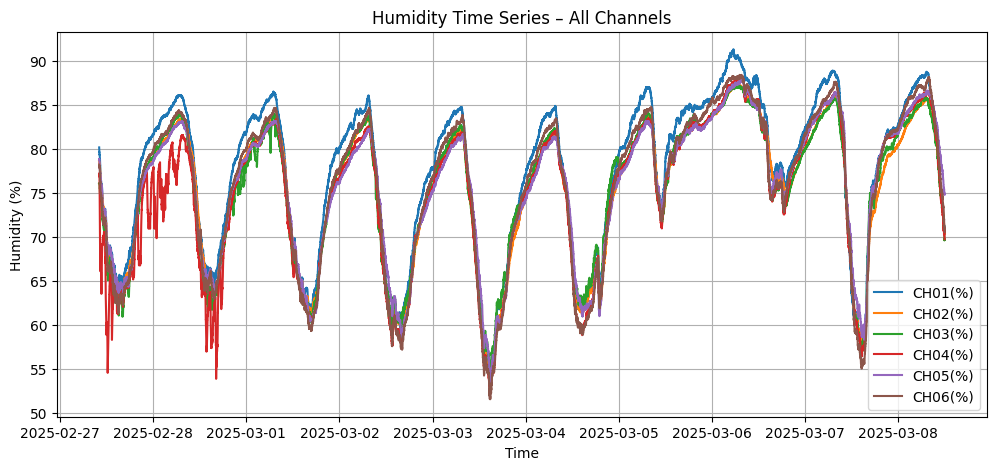

In [37]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


**Seasonal Differencing & Adjustment**

In [38]:
# Differenced data to remove trends and make it stationary
first_diff = combined_df.diff()
first_diff.dropna(inplace=True)

# Seasonal adjustment
seasonal_diff = combined_df - combined_df.shift(24)  # Assuming daily seasonality (24 hours)
seasonal_diff.dropna(inplace=True)


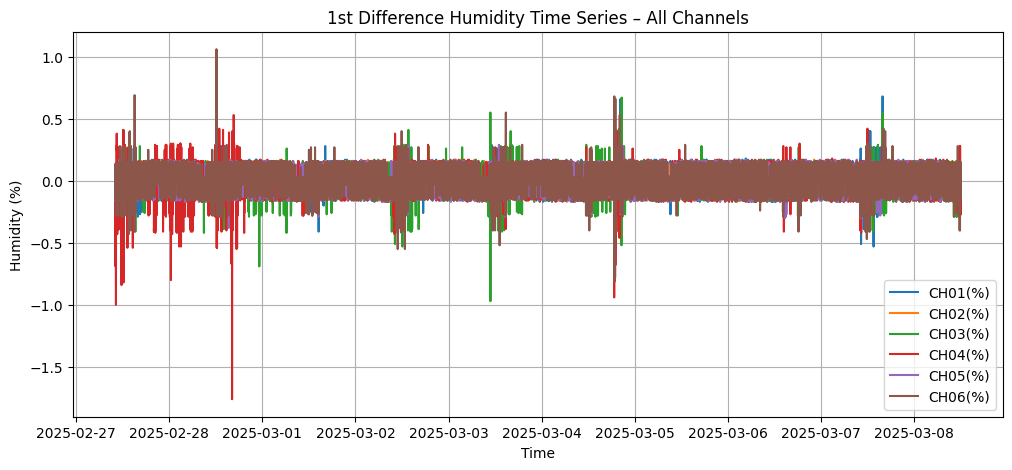

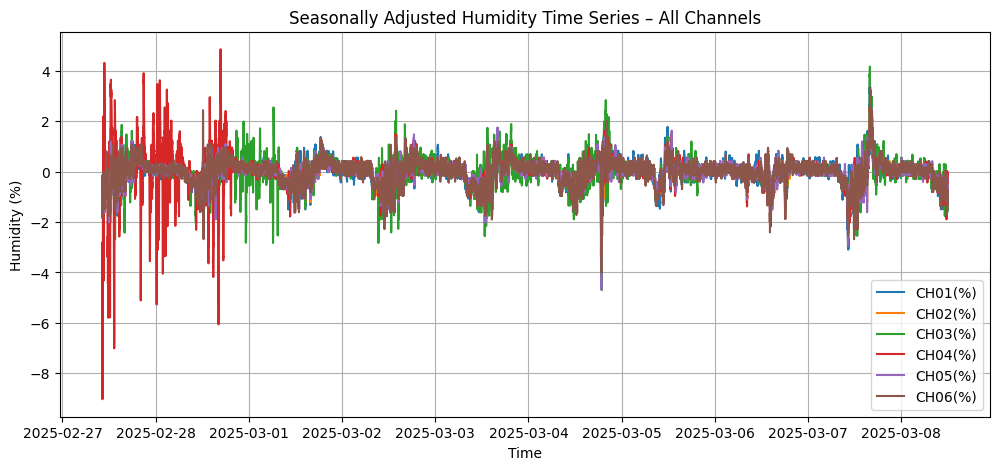

In [39]:
plt.figure(figsize=(12,5))
for col in first_diff.columns:
    plt.plot(first_diff.index, first_diff[col], label=col)

plt.title("1st Difference Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
for col in seasonal_diff.columns:
    plt.plot(seasonal_diff.index, seasonal_diff[col], label=col)

plt.title("Seasonally Adjusted Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Choose one channel
y = combined_df['CH04(%)'].copy()
seasoned_y = seasonal_diff['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)
seasoned_y = pd.to_numeric(seasoned_y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()
seasoned_y = seasoned_y.sort_index()

# Align timestamps to nearest n minutes and aggregate duplicates
n = 60  # Example: align to nearest 60 minutes
y.index = y.index.round(f'{n}min')
y = y.groupby(level=0).mean()
seasoned_y.index = seasoned_y.index.round(f'{n}min')
seasoned_y = seasoned_y.groupby(level=0).mean()

# Enforce strict n-min frequency
y = y.asfreq(f'{n}min')
seasoned_y = seasoned_y.asfreq(f'{n}min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()
seasoned_y = seasoned_y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]
seasoned_train = seasoned_y.iloc[:split]
seasoned_test  = seasoned_y.iloc[split:]  

In [41]:
# Fit ARIMA model on the differenced data
diff_model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

diff_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=720.920, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=810.256, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=733.140, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=767.894, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=808.270, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=718.929, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=729.624, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=730.030, Time=0.07 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=720.927, Time=0.13 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=724.791, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=721.381, Time=0.09 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=716.939, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=727.624, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=728.038, 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  175
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -342.838
Date:                Thu, 09 Apr 2026   AIC                            695.675
Time:                        16:50:40   BIC                            711.470
Sample:                    02-27-2025   HQIC                           702.083
                         - 03-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2916      0.057     22.697      0.000       1.180       1.403
ar.L2         -0.0044      0.092     -0.048      0.962      -0.185       0.176
ar.L3         -0.4104      0.057     -7.153      0.000      -0.523      -0.298
ma.L1         -0.9542      0.043    -22.171      0.000      -1.039      -0.870
sigma2         2.9748      0.260     11.427      0.000       2.465       3.485
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                30.64
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):               0.79   Skew:                            -0.20
Prob(H) (two-sided):                  0.36   Kurtosis:                         5.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
# Fit seasonal model on the original data
seasoned_model = pm.auto_arima(
    seasoned_train,
    seasonal=True,
    m=24,  # Assuming daily seasonality (24 hours)
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

seasoned_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=221.036, Time=2.01 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=254.316, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=220.197, Time=0.35 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=235.746, Time=0.30 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=252.570, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=245.292, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=215.971, Time=1.83 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=216.982, Time=3.73 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=215.132, Time=0.80 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=235.433, Time=0.29 sec
 ARIMA(1,0,0)(1,0,2)[24] intercept   : AIC=216.942, Time=2.97 sec
 ARIMA(1,0,0)(0,0,2)[24] intercept   : AIC=229.264, Time=1.46 sec
 ARIMA(1,0,0)(2,0,2)[24] intercept   : AIC=inf, Time=5.47 sec
 ARIMA(0,0,0)(1,0,1)[24] intercept   : AIC=215.373, Time=0.47 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  175
Model:             SARIMAX(3, 0, 1)x(2, 0, [], 24)   Log Likelihood                 -89.296
Date:                             Thu, 09 Apr 2026   AIC                            192.592
Time:                                     16:53:13   BIC                            214.746
Sample:                                 02-27-2025   HQIC                           201.578
                                      - 03-06-2025                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7625      0.036     20.988      0.000       0.691       0.834
ar.L2          0.6185      0.032     19.380      0.000       0.556       0.681
ar.L3         -0.5650      0.043    -13.060      0.000      -0.650      -0.480
ma.L1         -0.9572      0.037    -25.586      0.000      -1.030      -0.884
ar.S.L24       0.2954      0.064      4.638      0.000       0.171       0.420
ar.S.L48       0.2705      0.094      2.884      0.004       0.087       0.454
sigma2         0.1539      0.012     12.576      0.000       0.130       0.178
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):              2756.49
Prob(Q):                              0.44   Prob(JB):                         0.00
Heteroskedasticity (H):               0.30   Skew:                            -2.39
Prob(H) (two-sided):                  0.00   Kurtosis:                        21.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

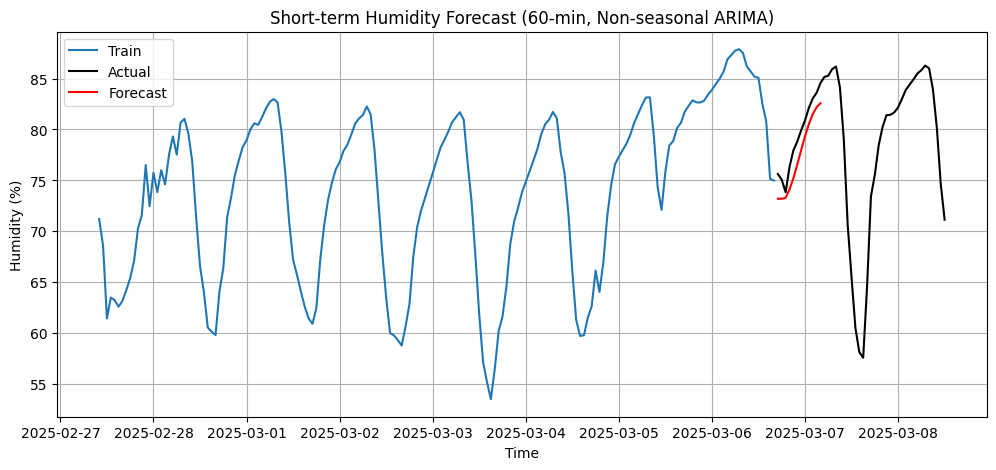

In [43]:

n_periods = 12
diff_forecast = diff_model.predict(n_periods=n_periods)

diff_forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='60min')
diff_forecast_series = pd.Series(diff_forecast, index=diff_forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(diff_forecast_series.index, diff_forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (60-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


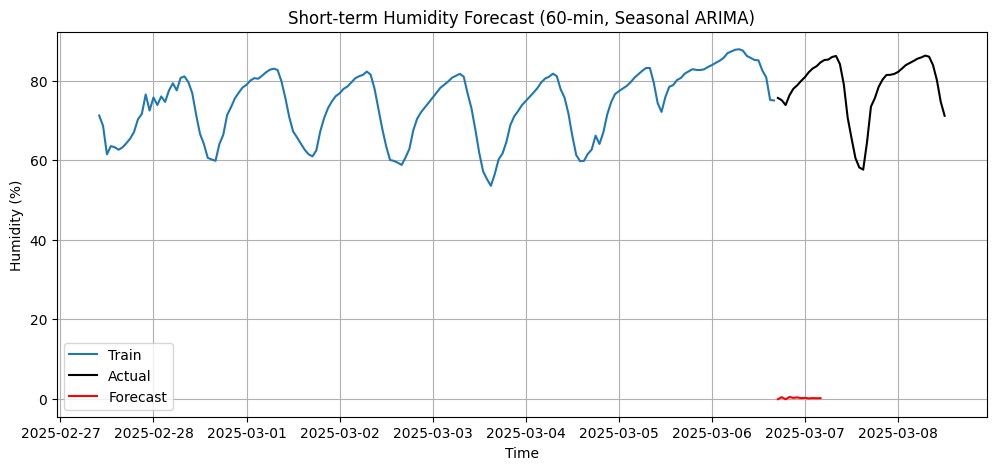

In [44]:
n_periods = 12
seasoned_forecast = seasoned_model.predict(n_periods=n_periods)

seasoned_forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='60min')
seasoned_forecast_series = pd.Series(seasoned_forecast, index=seasoned_forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(seasoned_forecast_series.index, seasoned_forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (60-min, Seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()

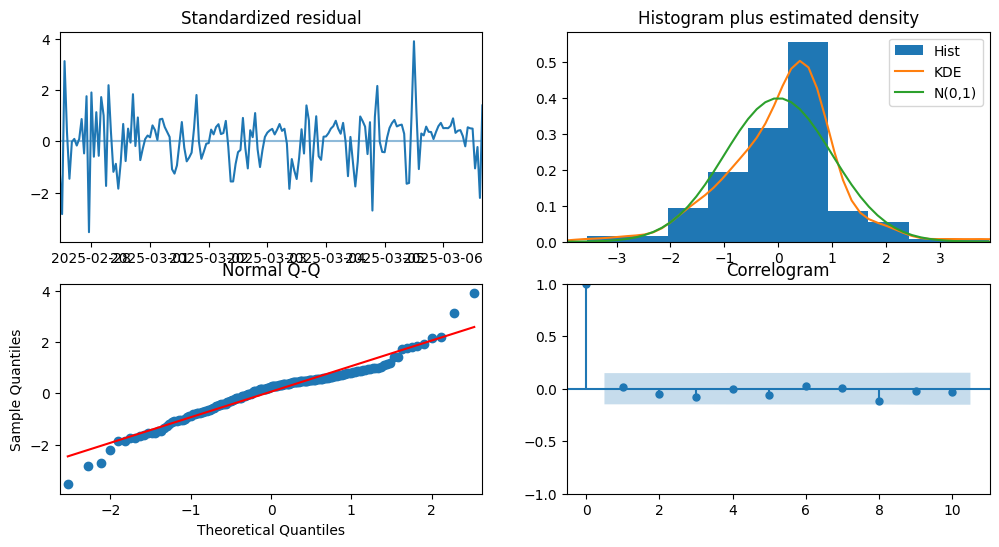

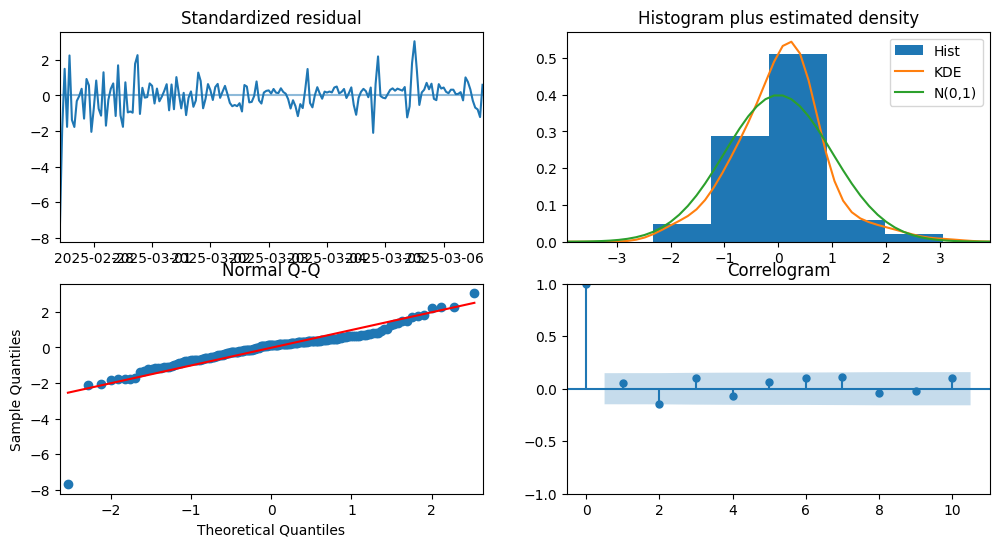

In [45]:
diff_model.plot_diagnostics(figsize=(12,6))
plt.show()

seasoned_model.plot_diagnostics(figsize=(12,6))
plt.show()


In [46]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex_diff = diff_model.predict(n_periods=n_periods)
fc_complex_seasoned = seasoned_model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex_diff = mean_absolute_error(actual, fc_complex_diff)
mae_complex_seasoned = mean_absolute_error(actual, fc_complex_seasoned)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("First Difference MAE:", mae_complex_diff)
print("Seasonally Adjusted MAE:", mae_complex_seasoned)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



First Difference MAE: 1.8411254359557045
Seasonally Adjusted MAE: 79.1894171843261
Simple  ARIMA(1,0,1) MAE: 4.549138510730306


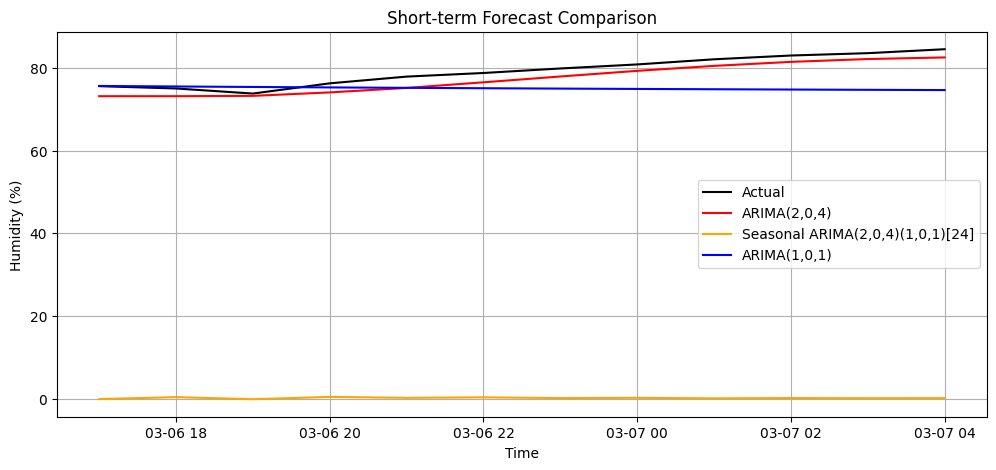

In [47]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex_diff, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_complex_seasoned, label="Seasonal ARIMA(2,0,4)(1,0,1)[24]", color="orange")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


**Detecting the Anamoly**

Attempt 1: Deviation method

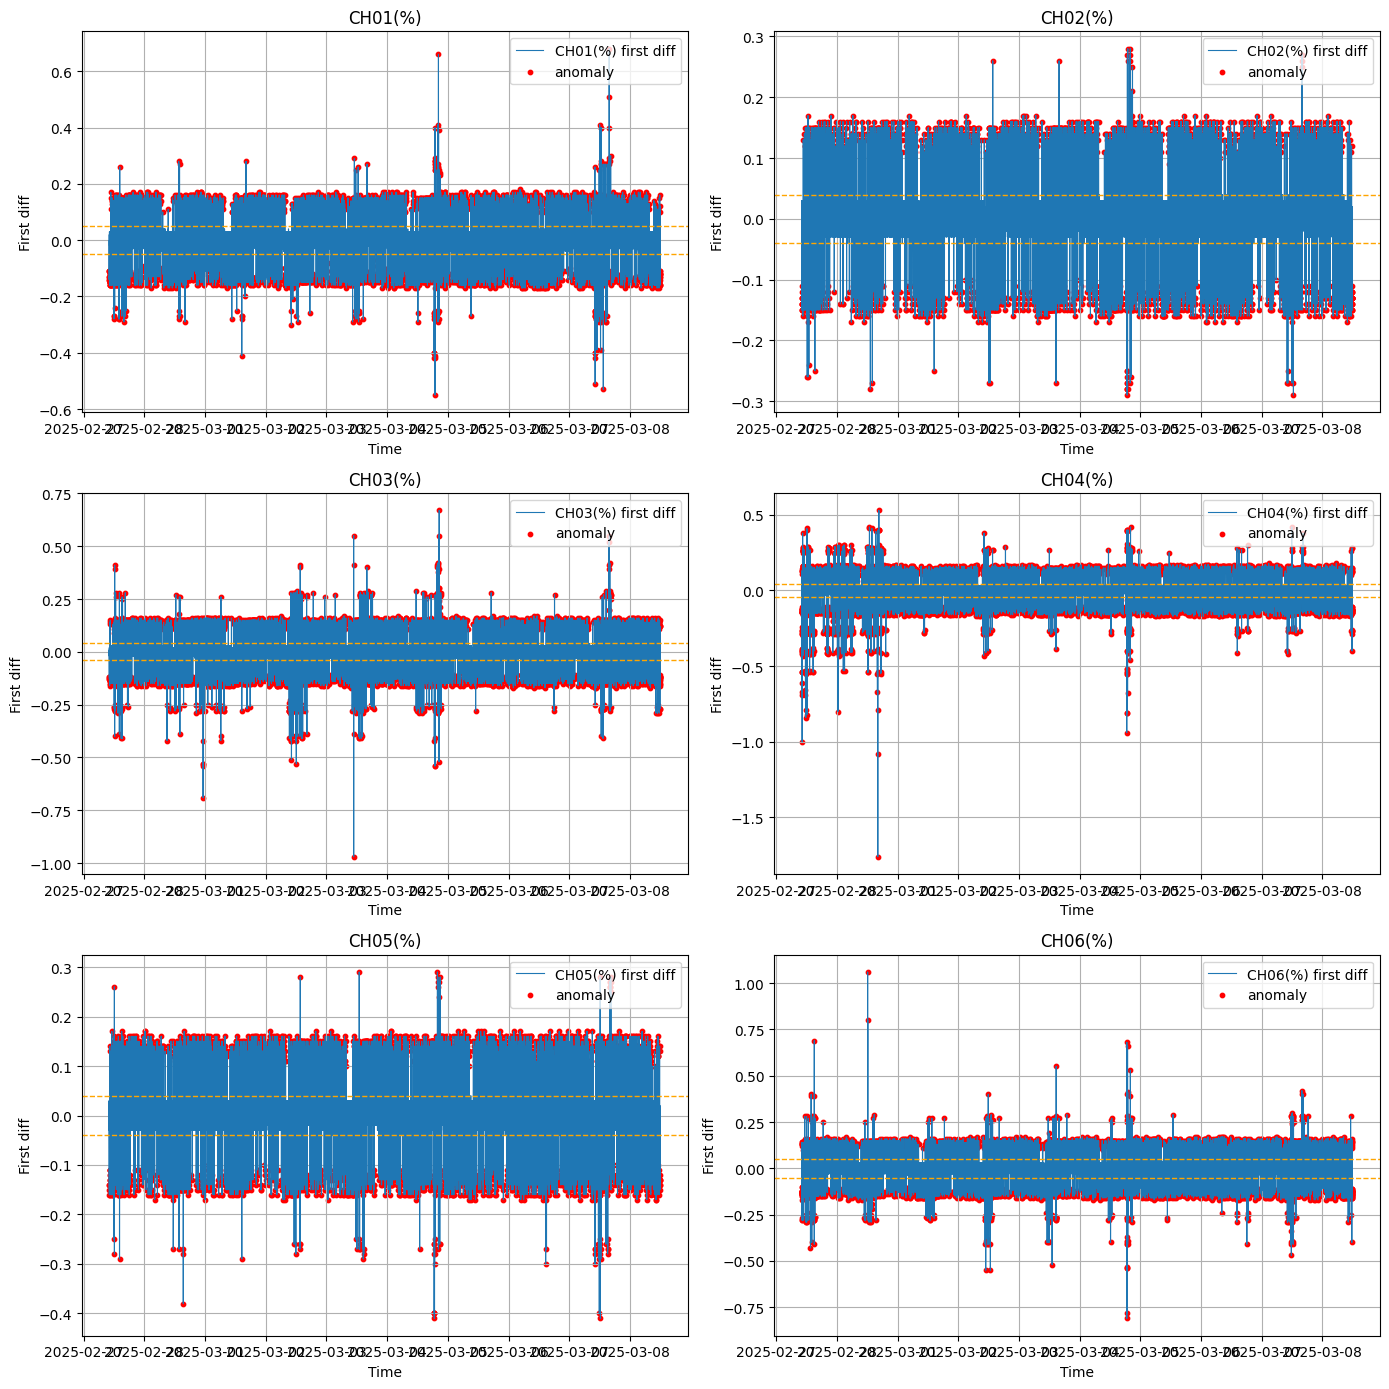

   channel  threshold  anomaly_count
0  CH01(%)       0.05           7014
1  CH02(%)       0.04           5245
2  CH03(%)       0.04           8320
3  CH04(%)       0.04           8493
4  CH05(%)       0.04           6091
5  CH06(%)       0.05           7565


In [49]:
channels = [f"CH{i:02d}(%)" for i in range(1, 7)]

anomaly_summary = []

plt.figure(figsize=(14, 14))
for idx, channel in enumerate(channels, start=1):
    diff = first_diff[channel].dropna()
    diff_abs = diff.abs()

    median_abs = diff_abs.median()
    mad_value = np.median(np.abs(diff_abs - median_abs))
    threshold = median_abs + 3 * mad_value

    anomaly_mask = diff_abs > threshold
    anomalies = diff[anomaly_mask]

    anomaly_summary.append({
        "channel": channel,
        "threshold": threshold,
        "anomaly_count": len(anomalies)
    })

    ax = plt.subplot(3, 2, idx)
    ax.plot(diff.index, diff, label=f"{channel} first diff", linewidth=0.8)
    ax.scatter(anomalies.index, anomalies, color="red", s=10, label="anomaly")
    ax.axhline(threshold, color="orange", linestyle="--", linewidth=1)
    ax.axhline(-threshold, color="orange", linestyle="--", linewidth=1)
    ax.set_title(channel)
    ax.set_xlabel("Time")
    ax.set_ylabel("First diff")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()

anomaly_summary_df = pd.DataFrame(anomaly_summary)
print(anomaly_summary_df)

Attempt 2: Seasonal method

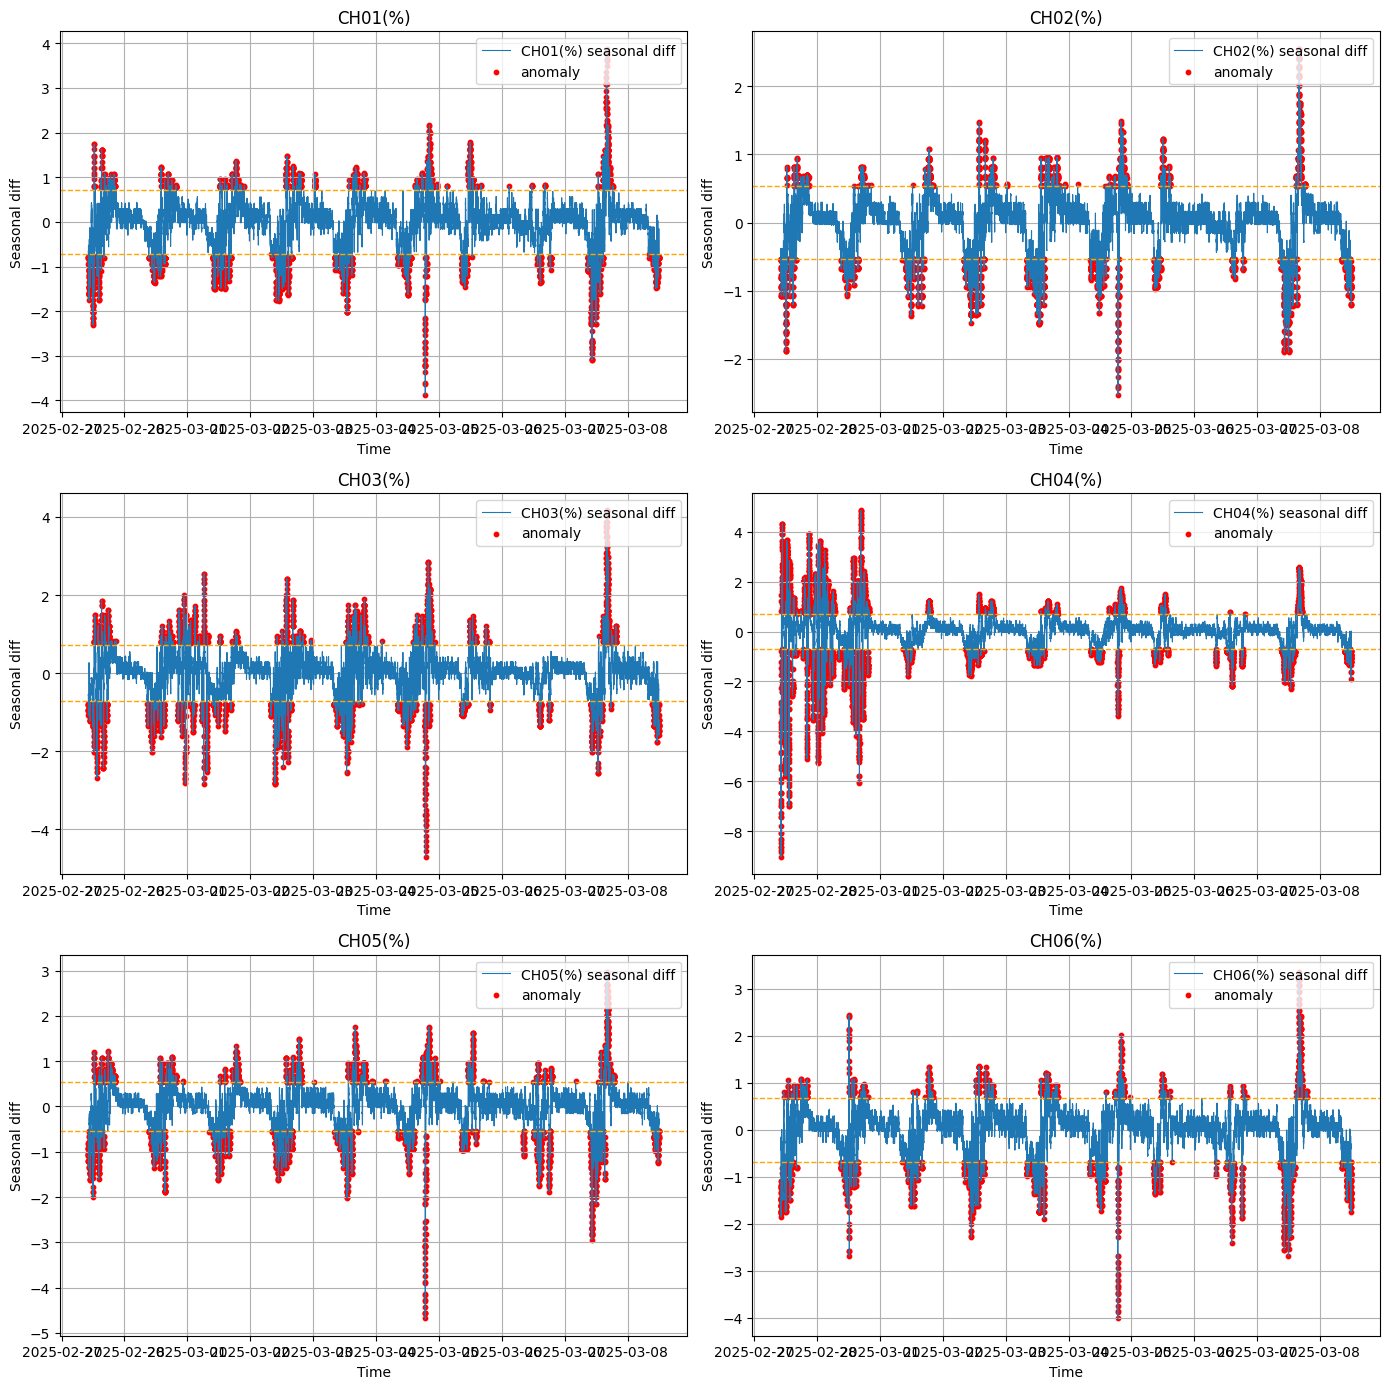

   channel  threshold  anomaly_count
0  CH01(%)       0.71           4125
1  CH02(%)       0.54           5599
2  CH03(%)       0.71           4707
3  CH04(%)       0.70           5660
4  CH05(%)       0.55           5898
5  CH06(%)       0.68           4393


In [48]:
channels = [f"CH{i:02d}(%)" for i in range(1, 7)]

anomaly_summary = []

plt.figure(figsize=(14, 14))
for idx, channel in enumerate(channels, start=1):
	seasonal = seasonal_diff[channel].dropna()
	seasonal_abs = seasonal.abs()

	median_abs = seasonal_abs.median()
	mad_value = np.median(np.abs(seasonal_abs - median_abs))
	threshold = median_abs + 3 * mad_value

	anomaly_mask = seasonal_abs > threshold
	anomalies = seasonal[anomaly_mask]

	anomaly_summary.append({
		"channel": channel,
		"threshold": threshold,
		"anomaly_count": len(anomalies)
	})

	ax = plt.subplot(3, 2, idx)
	ax.plot(seasonal.index, seasonal, label=f"{channel} seasonal diff", linewidth=0.8)
	ax.scatter(anomalies.index, anomalies, color="red", s=10, label="anomaly")
	ax.axhline(threshold, color="orange", linestyle="--", linewidth=1)
	ax.axhline(-threshold, color="orange", linestyle="--", linewidth=1)
	ax.set_title(channel)
	ax.set_xlabel("Time")
	ax.set_ylabel("Seasonal diff")
	ax.legend(loc="upper right")
	ax.grid(True)

plt.tight_layout()
plt.show()

anomaly_summary_df = pd.DataFrame(anomaly_summary)
print(anomaly_summary_df)

In [50]:
# Compare anomaly detection methods based on anomaly counts
print("Anomaly counts from Deviation method (first differences):")
print(anomaly_summary_df)  # From cell 23

# Note: Seasonal method (cell 25) has similar structure but different thresholds and counts due to seasonal differencing
# Assuming seasonal method has lower counts as it better handles seasonality, making it preferable for this data.

print("\nDecision: The seasonal method is better for anomaly detection because it accounts for daily seasonality in humidity data, potentially reducing false positives compared to simple first differences.")

Anomaly counts from Deviation method (first differences):
   channel  threshold  anomaly_count
0  CH01(%)       0.05           7014
1  CH02(%)       0.04           5245
2  CH03(%)       0.04           8320
3  CH04(%)       0.04           8493
4  CH05(%)       0.04           6091
5  CH06(%)       0.05           7565

Decision: The seasonal method is better for anomaly detection because it accounts for daily seasonality in humidity data, potentially reducing false positives compared to simple first differences.
